In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
dt_vals = [4, 12, 24, 48]
plots = {
    "TRP": ["L_[1, 0, 0]", "TRP_[1.0, 0.0, 0.0]", "TRP_[0.0, 1.0, 0.0]", "TRP_[0.0, 0.0, 1.0]", "TRP_[0.333, 0.333, 0.334]"],
    "RP": ["L_[1, 0, 0]", "RP_[1.0, 0.0, 0.0]", "RP_[0.0, 1.0, 0.0]", "RP_[0.0, 0.0, 1.0]", "RP_[0.333, 0.333, 0.334]"],
    "TP": ["L_[1, 0, 0]", "TP_[1.0, 0.0, 0.0]", "TP_[0.0, 1.0, 0.0]", "TP_[0.0, 0.0, 1.0]", "TP_[0.333, 0.333, 0.334]"],
    "[1.0, 0.0, 0.0]": ["L_[1, 0, 0]", "RP_[1.0, 0.0, 0.0]"] + [f"TP_[1.0, 0.0, 0.0]_dt{d}" for d in dt_vals] + [f"TRP_[1.0, 0.0, 0.0]_dt{d}" for d in dt_vals],
    "[0.0, 1.0, 0.0]": ["L_[1, 0, 0]", "TRP_[0.0, 1.0, 0.0]", "RP_[0.0, 1.0, 0.0]", "TP_[0.0, 1.0, 0.0]"],
    "[0.0, 0.0, 1.0]": ["L_[1, 0, 0]", "TRP_[0.0, 0.0, 1.0]", "RP_[0.0, 0.0, 1.0]", "TP_[0.0, 0.0, 1.0]"],
    "[0.333, 0.333, 0.334]": ["L_[1, 0, 0]", "TRP_[0.333, 0.333, 0.334]", "RP_[0.333, 0.333, 0.334]", "TP_[0.333, 0.333, 0.334]"]
}


In [ ]:
scenario = ""
workload = "spark"
provider = "aws"
mae = 0.1
period =  {
    "start": "2024-01-15T00:00:00Z",
    "end": "2024-01-22T00:00:00Z",
    "step": 60
}
schedulers = ["G", "R", "RP"]
seeds = [1,2,3,4,5]
weights = [
    "[1.0, 0.0, 0.0]",
    "[0.0, 1.0, 0.0]",
    "[0.0, 0.0, 1.0]",
    "[0.333, 0.333, 0.334]"

]
all_algorithms = ["L_[1, 0, 0]", 
                  "TRP_[1.0, 0.0, 0.0]", "TRP_[0.0, 1.0, 0.0]", "TRP_[0.0, 0.0, 1.0]", "TRP_[0.333, 0.333, 0.334]", 
                  "TP_[1.0, 0.0, 0.0]", "TP_[0.0, 1.0, 0.0]", "TP_[0.0, 0.0, 1.0]", "TP_[0.333, 0.333, 0.334]", 
                  "RP_[1.0, 0.0, 0.0]", "RP_[0.0, 1.0, 0.0]", "RP_[0.0, 0.0, 1.0]", "RP_[0.333, 0.333, 0.334]"]



plot_name = "[1.0, 0.0, 0.0]"

results_df = pd.DataFrame()
out_path = f"experiments/out/{provider}/{mae}/{period['start']}-{period['end']}/"
out_file = "e_{}_{}.csv".format
path_plot = f"experiments/out/{provider}/{mae}/{period['start']}-{period['end']}/plots/{plot_name}.pdf"
import os
if not os.path.exists(os.path.dirname(path_plot)):
    os.makedirs(os.path.dirname(path_plot))
    
for seed in seeds:
    for algorithm in all_algorithms:
        if "T" in algorithm:
            for dt in dt_vals:
                df = pd.read_csv(out_path + out_file(seed, algorithm + f"_dt{dt}"))
                df['seed'] = seed
                df['algorithm'] = algorithm + f"_dt{dt}"
                results_df = pd.concat([results_df, df], ignore_index=True)
        else:
            df = pd.read_csv(out_path + out_file(seed, algorithm))
            df['seed'] = seed
            df['algorithm'] = algorithm
            results_df = pd.concat([results_df, df], ignore_index=True)



In [ ]:
results_df.to_csv(out_path + "results_all.csv", index=False)

In [ ]:
results_df["date"] = pd.to_datetime(results_df["timestamp"], errors='coerce').dt.date

In [ ]:
results_df["date"]

In [ ]:
grouped = results_df.groupby(["algorithm", "seed", "date"]).agg(
    carbon_footprint_actual=pd.NamedAgg(column="carbon_actual", aggfunc=lambda x: (x * results_df.loc[x.index, "energy_kwh"]).sum()),
    carbon_footprint_forecast=pd.NamedAgg(column="carbon_forecast", aggfunc=lambda x: (x * results_df.loc[x.index, "energy_kwh"]).sum()),
    water_footprint_actual=pd.NamedAgg(column="water_actual", aggfunc=lambda x: (x * results_df.loc[x.index, "energy_kwh"]).sum()),
    water_footprint_forecast=pd.NamedAgg(column="water_forecast", aggfunc=lambda x: (x * results_df.loc[x.index, "energy_kwh"]).sum()),
    land_use_footprint_actual=pd.NamedAgg(column="land_use_actual", aggfunc=lambda x: (x * results_df.loc[x.index, "energy_kwh"]).sum()),
    land_use_footprint_forecast=pd.NamedAgg(column="land_use_forecast", aggfunc=lambda x: (x * results_df.loc[x.index, "energy_kwh"]).sum())
).reset_index()

In [ ]:
plt.figure(figsize=(16, 8))
grouped = grouped.sort_values("date")
for algo in grouped['algorithm'].unique():
    if "[1.0, 0.0, 0.0]" not in algo:
        continue
    algo_df = grouped[grouped['algorithm'] == algo]
    plt.errorbar(
        algo_df['date'],
        algo_df['carbon_footprint_actual'],
        yerr=algo_df['carbon_footprint_actual'].std(),
        label=algo
    )

plt.xlabel('Date')
plt.ylabel('Carbon Footprint Actual')
plt.title('Carbon Footprint Actual over Date by Algorithm (Errorbar: Seed Std)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Filter out the simulation_processing_time_seconds row if present
plot_df = results_df[results_df['timestamp'] != 'simulation_processing_time_seconds'].copy()

# Convert timestamp to datetime
plot_df['timestamp'] = pd.to_datetime(plot_df['timestamp'])

# Group by timestamp and algorithm, aggregate mean and std for carbon_actual over seeds
agg_df = plot_df.groupby(['timestamp', 'algorithm'])['carbon_actual'].agg(['mean', 'std']).reset_index()


In [ ]:

def plot(algorithms, agg_df, path_plot):
    # Filter the aggregated DataFrame for the selected algorithms
    filtered_df = agg_df[agg_df['algorithm'].isin(algorithms)]

    # Plot
    plt.figure(figsize=(16, 8))
    for algo in filtered_df['algorithm'].unique():
        algo_df = filtered_df[filtered_df['algorithm'] == algo]
        plt.errorbar(algo_df['timestamp'], algo_df['mean'], yerr=algo_df['std'], label=algo)

    plt.xlabel('Timestamp')
    plt.ylabel('Carbon Actual')
    plt.title('Carbon Actual over Time by Algorithm (Errorbar: Seed Std)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.savefig(path_plot+str(algorithms)+"pdf", bbox_inches='tight')

In [ ]:
plot(plots["[1.0, 0.0, 0.0]"], agg_df, path_plot)

In [21]:
import plotter.colors as colors
style = {
    "L_[1, 0, 0]": {
        "name": "Local",
        "color": "black",
        "alpha": 1,
        "marker": "o",
        "linestyle": "-",
    },
    "RP_[1.0, 0.0, 0.0]": {
        "name": "R - carbon",
        "color": colors.color_blind_palette[6],
        "alpha": 1,

        "marker": "s",
        "linestyle": "-",
    },
    "RP_[0.0, 1.0, 0.0]": {
        "name": "R - water",
        "color": colors.color_blind_palette[4],
        "alpha": 1,
        "marker": "s",
        "linestyle": "-",
    },
    "RP_[0.0, 0.0, 1.0]": {
        "name": "R - land",
        "color": colors.color_blind_palette[3],
        "alpha": 1,
        "marker": "s",
        "linestyle": "-",
    },
    "RP_[0.333, 0.333, 0.334]": {
        "name": "R - mix",
        "color": colors.color_blind_palette[2],
        "alpha": 1,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[1.0, 0.0, 0.0]_dt4": {
        "name": "T (dt4) - carbon",
        "color": colors.color_blind_palette[6],
        "alpha": 0.4,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[0.0, 1.0, 0.0]_dt4": {
        "name": "T (dt4) - water",
        "color": colors.color_blind_palette[4],
        "alpha": 0.4,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[0.0, 0.0, 1.0]_dt4": {
        "name": "T (dt4)- land",
        "color": colors.color_blind_palette[3],
        "alpha": 0.4,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[0.333, 0.333, 0.334]_dt4": {
        "name": "T (dt4) - mix",
        "color": colors.color_blind_palette[2],
        "alpha": 0.4,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[1.0, 0.0, 0.0]_dt12": {
        "name": "T (dt12) - carbon",
        "color": colors.color_blind_palette[6],
        "alpha": 0.6,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[0.0, 1.0, 0.0]_dt12": {
        "name": "T (dt12) - water",
        "color": colors.color_blind_palette[4],
        "alpha": 0.6,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[0.0, 0.0, 1.0]_dt12": {
        "name": "T (dt12) - land",
        "color": colors.color_blind_palette[3],
        "alpha": 0.6,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[0.333, 0.333, 0.334]_dt12": {
        "name": "T (dt12) - mix",
        "color": colors.color_blind_palette[2],
        "alpha": 0.6,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[1.0, 0.0, 0.0]_dt24": {
        "name": "T (dt24) - carbon",
        "color": colors.color_blind_palette[6],
        "alpha": 0.8,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[0.0, 1.0, 0.0]_dt24": {
        "name": "T (dt24) - water",
        "color": colors.color_blind_palette[4],
        "alpha": 0.8,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[0.0, 0.0, 1.0]_dt24": {
        "name": "T (dt24) - land",
        "color": colors.color_blind_palette[3],
        "alpha": 0.8,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[0.333, 0.333, 0.334]_dt24": {
        "name": "T (dt24) - mix",
        "color": colors.color_blind_palette[2],
        "alpha": 0.8,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[1.0, 0.0, 0.0]_dt48": {
        "name": "T (dt48) - carbon",
        "color": colors.color_blind_palette[6],
        "alpha": 1,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[0.0, 1.0, 0.0]_dt48": {
        "name": "T (dt48) - water",
        "color": colors.color_blind_palette[4],
        "alpha": 1,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[0.0, 0.0, 1.0]_dt48": {
        "name": "T (dt48) - land",
        "color": colors.color_blind_palette[3],
        "alpha": 1,
        "marker": "s",
        "linestyle": "-",
    },
    "TP_[0.333, 0.333, 0.334]_dt48": {
        "name": "T (dt48) - mix",
        "color": colors.color_blind_palette[2],
        "alpha": 1,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[1.0, 0.0, 0.0]_dt4": {
        "name": "TR (dt4) - carbon",
        "color": colors.color_blind_palette[6],
        "alpha": 0.4,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[0.0, 1.0, 0.0]_dt4": {
        "name": "TR (dt4) - water",
        "color": colors.color_blind_palette[4],
        "alpha": 0.4,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[0.0, 0.0, 1.0]_dt4": {
        "name": "TR (dt4)- land",
        "color": colors.color_blind_palette[3],
        "alpha": 0.4,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[0.333, 0.333, 0.334]_dt4": {
        "name": "TR (dt4) - mix",
        "color": colors.color_blind_palette[2],
        "alpha": 0.4,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[1.0, 0.0, 0.0]_dt12": {
        "name": "TR (dt12) - carbon",
        "color": colors.color_blind_palette[6],
        "alpha": 0.6,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[0.0, 1.0, 0.0]_dt12": {
        "name": "TR (dt12) - water",
        "color": colors.color_blind_palette[4],
        "alpha": 0.6,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[0.0, 0.0, 1.0]_dt12": {
        "name": "TR (dt12) - land",
        "color": colors.color_blind_palette[3],
        "alpha": 0.6,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[0.333, 0.333, 0.334]_dt12": {
        "name": "TR (dt12) - mix",
        "color": colors.color_blind_palette[2],
        "alpha": 0.6,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[1.0, 0.0, 0.0]_dt24": {
        "name": "TR (dt24) - carbon",
        "color": colors.color_blind_palette[6],
        "alpha": 0.8,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[0.0, 1.0, 0.0]_dt24": {
        "name": "TR (dt24) - water",
        "color": colors.color_blind_palette[4],
        "alpha": 0.8,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[0.0, 0.0, 1.0]_dt24": {
        "name": "TR (dt24) - land",
        "color": colors.color_blind_palette[3],
        "alpha": 0.8,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[0.333, 0.333, 0.334]_dt24": {
        "name": "TR (dt24) - mix",
        "color": colors.color_blind_palette[2],
        "alpha": 0.8,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[1.0, 0.0, 0.0]_dt48": {
        "name": "TR (dt48) - carbon",
        "color": colors.color_blind_palette[6],
        "alpha": 1,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[0.0, 1.0, 0.0]_dt48": {
        "name": "TR (dt48) - water",
        "color": colors.color_blind_palette[4],
        "alpha": 1,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[0.0, 0.0, 1.0]_dt48": {
        "name": "TR (dt48) - land",
        "color": colors.color_blind_palette[3],
        "alpha": 1,
        "marker": "s",
        "linestyle": "-",
    },
    "TRP_[0.333, 0.333, 0.334]_dt48": {
        "name": "TR (dt48) - mix",
        "color": colors.color_blind_palette[2],
        "alpha": 1,
        "marker": "s",
        "linestyle": "-",
    },
    
    



}

In [ ]:
results_df = results_df[results_df['timestamp'] != 'simulation_processing_time_seconds']
grouped = results_df.groupby(["seed", "timestamp"]).agg(
    carbon_footprint_actual=pd.NamedAgg(column="carbon_actual", aggfunc=lambda x: (x * results_df.loc[x.index, "energy_kwh"]).sum()),
    carbon_footprint_forecast=pd.NamedAgg(column="carbon_forecast", aggfunc=lambda x: (x * results_df.loc[x.index, "energy_kwh"]).sum()),
    water_footprint_actual=pd.NamedAgg(column="water_actual", aggfunc=lambda x: (x * results_df.loc[x.index, "energy_kwh"]).sum()),
    water_footprint_forecast=pd.NamedAgg(column="water_forecast", aggfunc=lambda x: (x * results_df.loc[x.index, "energy_kwh"]).sum()),
    land_use_footprint_actual=pd.NamedAgg(column="land_use_actual", aggfunc=lambda x: (x * results_df.loc[x.index, "energy_kwh"]).sum()),
    land_use_footprint_forecast=pd.NamedAgg(column="land_use_forecast", aggfunc=lambda x: (x * results_df.loc[x.index, "energy_kwh"]).sum())
).reset_index()

In [ ]:
df["timestamp"].unique()

In [ ]:
freq = "1H" #  1 hour
granular_df = grouped.assign(
    timestamp=pd.to_datetime(grouped["timestamp"])
).set_index("timestamp").groupby([
    "seed", 
    pd.Grouper(freq=freq)
]).agg({
    "carbon_footprint_actual": "sum",
    "carbon_footprint_forecast": "sum",
    "water_footprint_actual": "sum",
    "water_footprint_forecast": "sum",
    "land_use_footprint_actual": "sum",
    "land_use_footprint_forecast": "sum"
}).reset_index()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Sort by timestamp
granular_df_sorted = granular_df.sort_values("timestamp")
import matplotlib.pyplot as plt

# Aggregate mean and std over seeds for each timestamp
agg = granular_df_sorted.groupby("timestamp").agg(
    carbon_actual_mean=("carbon_footprint_actual", "mean"),
    carbon_actual_std=("carbon_footprint_actual", "std"),
    carbon_forecast_mean=("carbon_footprint_forecast", "mean"),
    carbon_forecast_std=("carbon_footprint_forecast", "std"),
).reset_index()

plt.figure(figsize=(16, 8))
plt.errorbar(
    agg["timestamp"], agg["carbon_actual_mean"], yerr=agg["carbon_actual_std"],
    label="Carbon Footprint Actual", fmt='-o'
)
plt.errorbar(
    agg["timestamp"], agg["carbon_forecast_mean"], yerr=agg["carbon_forecast_std"],
    label="Carbon Footprint Forecast", fmt='-s'
)
plt.xlabel("Timestamp")
plt.ylabel("Carbon Footprint")
plt.title("Carbon Footprint Actual and Forecast over Time (Errorbar: Seed Std)")
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Evaluating regional shifting

In [2]:
seeds = [1,2,3,4,5,6]
workload = "spark"
provider = "aws"
mae = 0.05
period =  {
    "start": "2024-07-15T00:00:00Z",
    "end": "2024-07-22T00:00:00Z",
    "step": 60
}
out_path = f"experiments/out/{provider}/{mae}/{period['start']}-{period['end']}/"
out_file = "e_{}_{}.csv".format

In [ ]:
algorithms = ["L_[1, 0, 0]", "RP_[1.0, 0.0, 0.0]", "RP_[0.0, 1.0, 0.0]", "RP_[0.0, 0.0, 1.0]"]#, "RP_[0.333, 0.333, 0.334]"]

In [ ]:
algorithms = ["L_[1, 0, 0]", 
              "TP_[1.0, 0.0, 0.0]_dt4", "TP_[1.0, 0.0, 0.0]_dt12", "TP_[1.0, 0.0, 0.0]_dt24", "TP_[1.0, 0.0, 0.0]_dt48"
              ]


In [ ]:
dfs = {
    algo: pd.DataFrame() for algo in algorithms
}

for algo in algorithms:
    for seed in seeds:
        df = pd.read_csv(out_path + out_file(seed, algo))
        df['seed'] = seed
        dfs[algo] = pd.concat([dfs[algo], df], ignore_index=True)

    dfs[algo] = dfs[algo][dfs[algo]['timestamp'] != 'simulation_processing_time_seconds']
    dfs[algo] = dfs[algo].groupby(["seed", "timestamp"]).agg(
        carbon_footprint_actual=pd.NamedAgg(column="carbon_actual", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum()),
        carbon_footprint_forecast=pd.NamedAgg(column="carbon_forecast", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum()),
        water_footprint_actual=pd.NamedAgg(column="water_actual", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum()),
        water_footprint_forecast=pd.NamedAgg(column="water_forecast", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum()),
        land_use_footprint_actual=pd.NamedAgg(column="land_use_actual", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum()),
        land_use_footprint_forecast=pd.NamedAgg(column="land_use_forecast", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum())
    ).reset_index().sort_values("timestamp")

In [34]:
import numpy as np
def plot_footprint_comparison(algorithms, factor, freq, plot_type="errorbar", mix_type="actual", seed=None):
    # Aggregate mean and std over seeds for each timestamp
    plt.figure(figsize=(16, 8))
    for algo in algorithms:
        if seed is not None:
            df = dfs[algo][dfs[algo]['seed'] == seed]
        else:
            df = dfs[algo]
        granular_df = df.assign(
            timestamp=pd.to_datetime(df["timestamp"])
        ).set_index("timestamp").groupby([
            "seed", 
            pd.Grouper(freq=freq)
        ]).agg({
            "carbon_footprint_actual": "sum",
            "carbon_footprint_forecast": "sum",
            "water_footprint_actual": "sum",
            "water_footprint_forecast": "sum",
            "land_use_footprint_actual": "sum",
            "land_use_footprint_forecast": "sum"
        }).reset_index()

    
        agg = granular_df.groupby("timestamp").agg(
            mean=(f"{factor}_footprint_{mix_type}", "mean"),
            std=(f"{factor}_footprint_{mix_type}", "std"),
        ).reset_index()
        if plot_type == "histogram":
            # Offset the bars for each algorithm to avoid overlap
            width = 0.18  # width of each bar
            idx = algorithms.index(algo)
            offsets = np.arange(len(agg["timestamp"]))
            plt.bar(
                offsets + idx * width, agg["mean"], width=width, yerr=agg["std"],
                label=style[algo]["name"], alpha=style[algo]["alpha"], color=style[algo]["color"], edgecolor='black'
            )
            plt.xticks(offsets + width * (len(algorithms) - 1) / 2, agg["timestamp"], rotation=45)
        else:
            plt.errorbar(
                agg["timestamp"], agg["mean"], yerr=agg["std"],
                label=style[algo]["name"], fmt='-o', alpha=style[algo]["alpha"], color=style[algo]["color"]
            )

    plt.xlabel("Timestamp")
    plt.ylabel(f"{factor} footprint")
    #plt.title("Carbon Footprint Actual and Forecast over Time (Errorbar: Seed Std)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plot_path = f"experiments/out/{provider}/{mae}/{period['start']}-{period['end']}/plots/"
    if not os.path.exists(os.path.dirname(plot_path)):
        os.makedirs(os.path.dirname(plot_path))
    #plt.savefig(f"{plot_path}{str(algorithms[-1])}{factor}_{freq}_{mix_type}_{plot_type}.pdf", bbox_inches='tight')

In [33]:
import numpy as np
def plot_footprint_improvement(algorithms, reference, factor, freq, plot_type="errorbar", mix_type="actual", seed=None):
    print((algorithms, reference, factor))

    # Aggregate mean and std over seeds for each timestamp
    plt.figure(figsize=(16, 8))
    reference_df = dfs[reference].assign(
        timestamp=pd.to_datetime( dfs[reference]["timestamp"])
    ).set_index("timestamp").groupby([
        "seed", 
        pd.Grouper(freq=freq)
    ]).agg({
        "carbon_footprint_actual": "sum",
        "carbon_footprint_forecast": "sum",
        "water_footprint_actual": "sum",
        "water_footprint_forecast": "sum",
        "land_use_footprint_actual": "sum",
        "land_use_footprint_forecast": "sum"
    }).reset_index()
    reference_df = reference_df.groupby("timestamp").agg(
        mean=(f"{factor}_footprint_{mix_type}", "mean"),
        std=(f"{factor}_footprint_{mix_type}", "std"),
    ).reset_index()
    
    for algo in algorithms:
        print(algo)

        if seed is not None:
            df = dfs[algo][dfs[algo]['seed'] == seed]
        else:
            df = dfs[algo]
        granular_df = df.assign(
            timestamp=pd.to_datetime(df["timestamp"])
        ).set_index("timestamp").groupby([
            "seed", 
            pd.Grouper(freq=freq)
        ]).agg({
            "carbon_footprint_actual": "sum",
            "carbon_footprint_forecast": "sum",
            "water_footprint_actual": "sum",
            "water_footprint_forecast": "sum",
            "land_use_footprint_actual": "sum",
            "land_use_footprint_forecast": "sum"
        }).reset_index()

        # Compute improvement over reference: (reference - algo) / reference
        # Align timestamps between agg and reference_df
        agg = granular_df.groupby("timestamp").agg(
            mean=(f"{factor}_footprint_{mix_type}", "mean"),
            std=(f"{factor}_footprint_{mix_type}", "std"),
        ).reset_index()

        merged = pd.merge(agg, reference_df, on="timestamp", suffixes=("_algo", "_ref"))
        # Calculate relative improvement (positive means reduction)
        merged["improvement_mean"] = (merged["mean_ref"] - merged["mean_algo"]) / merged["mean_ref"]
        merged["improvement_std"] = merged["std_algo"] / merged["mean_ref"]

        agg = merged[["timestamp", "improvement_mean", "improvement_std"]].rename(
            columns={"improvement_mean": "mean", "improvement_std": "std"}
        )

        if plot_type == "histogram":
            # Offset the bars for each algorithm to avoid overlap
            width = 0.18  # width of each bar
            idx = algorithms.index(algo)
            offsets = np.arange(len(agg["timestamp"]))
            plt.bar(
                offsets + idx * width, agg["mean"], width=width, yerr=agg["std"],
                label=style[algo]["name"], alpha=style[algo]["alpha"], color=style[algo]["color"], edgecolor='black'

            )
            plt.xticks(offsets + width * (len(algorithms) - 1) / 2, agg["timestamp"], rotation=45)
        else:
            plt.errorbar(
                agg["timestamp"], agg["mean"], yerr=agg["std"],
                label=style[algo]["name"], fmt='-o', alpha=style[algo]["alpha"], color=style[algo]["color"]
            )

    plt.xlabel("Timestamp")
    plt.ylabel(f"{factor} footprint improvement over {style[reference]["name"]}")
    #plt.title("Carbon Footprint Actual and Forecast over Time (Errorbar: Seed Std)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    plot_path = f"experiments/out/{provider}/{mae}/{period['start']}-{period['end']}/plots/"
    if not os.path.exists(os.path.dirname(plot_path)):
        os.makedirs(os.path.dirname(plot_path))
    #plt.savefig(f"{plot_path}{str(algorithms[-1])}{factor}_{freq}_{mix_type}_{plot_type}_improvement.pdf", bbox_inches='tight')

In [ ]:
plot_footprint_comparison(algorithms, "carbon", "1H", mix_type="forecast", seed=1)


In [ ]:
plot_footprint_comparison(algorithms, "water", "1H", mix_type="forecast")


In [ ]:
plot_footprint_comparison(algorithms[-1:], "land_use", "1H", mix_type="forecast")


In [ ]:

plot_footprint_comparison(algorithms, "carbon", "1H")


In [ ]:
plot_footprint_comparison(algorithms, "water", "1H")


In [ ]:
plot_footprint_comparison(algorithms, "land_use", "1H")


In [ ]:
plot_footprint_comparison(algorithms, "carbon", "1D", "histogram")

In [ ]:
plot_footprint_comparison(algorithms, "water", "1D", "histogram")

In [ ]:
plot_footprint_comparison(algorithms, "land_use", "1D", "histogram")

In [ ]:
plot_footprint_improvement(algorithms=algorithms[1:], reference=algorithms[0], factor="water", freq="1D", plot_type="histogram")

In [ ]:
plot_footprint_improvement(algorithms=algorithms[1:], reference=algorithms[0], factor="carbon", freq="1W", plot_type="histogram")

In [25]:
reference = "L_[1, 0, 0]"
R_algorithms = [
    "RP_[1.0, 0.0, 0.0]",
    "RP_[0.0, 1.0, 0.0]",
    "RP_[0.0, 0.0, 1.0]",
    "RP_[0.333, 0.333, 0.334]"
]
T_algorithms = [
    "TP_[1.0, 0.0, 0.0]_dt4", 
    "TP_[1.0, 0.0, 0.0]_dt12", 
    "TP_[1.0, 0.0, 0.0]_dt24", 
    "TP_[1.0, 0.0, 0.0]_dt48",
    "TP_[0.0, 1.0, 0.0]_dt4", 
    "TP_[0.0, 1.0, 0.0]_dt12", 
    "TP_[0.0, 1.0, 0.0]_dt24", 
    "TP_[0.0, 1.0, 0.0]_dt48",
    "TP_[0.0, 0.0, 1.0]_dt4", 
    "TP_[0.0, 0.0, 1.0]_dt12", 
    "TP_[0.0, 0.0, 1.0]_dt24", 
    "TP_[0.0, 0.0, 1.0]_dt48",
    "TP_[0.333, 0.333, 0.334]_dt4", 
    "TP_[0.333, 0.333, 0.334]_dt12", 
    "TP_[0.333, 0.333, 0.334]_dt24", 
    "TP_[0.333, 0.333, 0.334]_dt48"
]   

TR_algorithms = [
    "TRP_[1.0, 0.0, 0.0]_dt4", 
    "TRP_[1.0, 0.0, 0.0]_dt12", 
    "TRP_[1.0, 0.0, 0.0]_dt24", 
    "TRP_[1.0, 0.0, 0.0]_dt48",
    "TRP_[0.0, 1.0, 0.0]_dt4", 
    "TRP_[0.0, 1.0, 0.0]_dt12", 
    "TRP_[0.0, 1.0, 0.0]_dt24", 
    "TRP_[0.0, 1.0, 0.0]_dt48",
    "TRP_[0.0, 0.0, 1.0]_dt4", 
    "TRP_[0.0, 0.0, 1.0]_dt12", 
    "TRP_[0.0, 0.0, 1.0]_dt24", 
    "TRP_[0.0, 0.0, 1.0]_dt48",
    "TRP_[0.333, 0.333, 0.334]_dt4", 
    "TRP_[0.333, 0.333, 0.334]_dt12", 
    "TRP_[0.333, 0.333, 0.334]_dt24", 
    "TRP_[0.333, 0.333, 0.334]_dt48"
]   
plots_T = [


    {
        "function" : plot_footprint_improvement,
        "args": {
            "algorithms": T_algorithms,
            "reference": reference,
            "factor": "carbon",
            "freq": "1W",
            "plot_type": "histogram",
        }
    }, 
    {
        "function" : plot_footprint_improvement,
        "args": {
            "algorithms": T_algorithms,
            "reference": reference,
            "factor": "water",
            "freq": "1W",
            "plot_type": "histogram",
        }
    },
    {
        "function" : plot_footprint_improvement,
        "args": {
            "algorithms": T_algorithms,
            "reference": reference,
            "factor": "land_use",
            "freq": "1W",
            "plot_type": "histogram",
        }
    }
]

plots_TR = [
    {
        "function" : plot_footprint_improvement,
        "args": {
            "algorithms": TR_algorithms,
            "reference": reference,
            "factor": "carbon",
            "freq": "1W",
            "plot_type": "histogram",
        }
    }, 
    {
        "function" : plot_footprint_improvement,
        "args": {
            "algorithms": TR_algorithms,
            "reference": reference,
            "factor": "water",
            "freq": "1W",
            "plot_type": "histogram",
        }
    },
    {
        "function" : plot_footprint_improvement,
        "args": {
            "algorithms": TR_algorithms,
            "reference": reference,
            "factor": "land_use",
            "freq": "1W",
            "plot_type": "histogram",
        }
    }
]

In [6]:
plots_R = [
    {
        "function" : plot_footprint_comparison,
        "args": {
            "algorithms": R_algorithms + [reference],
            "factor": "carbon",
            "freq": "1W",
            "plot_type": "histogram"

        }
    },
    {
        "function" : plot_footprint_comparison,
        "args": {
            "algorithms": R_algorithms + [reference],
            "factor": "water",
            "freq": "1W",
            "plot_type": "histogram"

        }
    },
    {
        "function" : plot_footprint_comparison,
        "args": {
            "algorithms": R_algorithms + [reference],
            "factor": "land_use",
            "freq": "1W",
            "plot_type": "histogram"
        }
    },
]

In [8]:
dfs = {
    
}


In [9]:
algo = reference
dfs[algo] = pd.DataFrame()
for seed in seeds:
    df = pd.read_csv(out_path + out_file(seed, algo))
    df['seed'] = seed
    dfs[algo] = pd.concat([dfs[algo], df], ignore_index=True)

    dfs[algo] = dfs[algo][dfs[algo]['timestamp'] != 'simulation_processing_time_seconds']
    dfs[algo] = dfs[algo].groupby(["seed", "timestamp"]).agg(
        carbon_footprint_actual=pd.NamedAgg(column="carbon_actual", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum()),
        carbon_footprint_forecast=pd.NamedAgg(column="carbon_forecast", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum()),
        water_footprint_actual=pd.NamedAgg(column="water_actual", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum()),
        water_footprint_forecast=pd.NamedAgg(column="water_forecast", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum()),
        land_use_footprint_actual=pd.NamedAgg(column="land_use_actual", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum()),
        land_use_footprint_forecast=pd.NamedAgg(column="land_use_forecast", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum())
    ).reset_index().sort_values("timestamp")

In [17]:
for plot in plots:
    for algo in plot["args"]["algorithms"]:
        if algo not in dfs:
            dfs[algo] = pd.DataFrame()
            for seed in seeds:
                df = pd.read_csv(out_path + out_file(seed, algo))
                df['seed'] = seed
                dfs[algo] = pd.concat([dfs[algo], df], ignore_index=True)

                dfs[algo] = dfs[algo][dfs[algo]['timestamp'] != 'simulation_processing_time_seconds']
                dfs[algo] = dfs[algo].groupby(["seed", "timestamp"]).agg(
                    carbon_footprint_actual=pd.NamedAgg(column="carbon_actual", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum()),
                    carbon_footprint_forecast=pd.NamedAgg(column="carbon_forecast", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum()),
                    water_footprint_actual=pd.NamedAgg(column="water_actual", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum()),
                    water_footprint_forecast=pd.NamedAgg(column="water_forecast", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum()),
                    land_use_footprint_actual=pd.NamedAgg(column="land_use_actual", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum()),
                    land_use_footprint_forecast=pd.NamedAgg(column="land_use_forecast", aggfunc=lambda x: (x * dfs[algo].loc[x.index, "energy_kwh"]).sum())
                ).reset_index().sort_values("timestamp")

In [23]:
dfs.keys()

dict_keys(['L_[1, 0, 0]', 'RP_[1.0, 0.0, 0.0]', 'RP_[0.0, 1.0, 0.0]', 'RP_[0.0, 0.0, 1.0]', 'RP_[0.333, 0.333, 0.334]', 'TP_[1.0, 0.0, 0.0]_dt4', 'TP_[1.0, 0.0, 0.0]_dt12', 'TP_[1.0, 0.0, 0.0]_dt24', 'TP_[1.0, 0.0, 0.0]_dt48', 'TP_[0.0, 1.0, 0.0]_dt4', 'TP_[0.0, 1.0, 0.0]_dt12', 'TP_[0.0, 1.0, 0.0]_dt24', 'TP_[0.0, 1.0, 0.0]_dt48', 'TP_[0.0, 0.0, 1.0]_dt4', 'TP_[0.0, 0.0, 1.0]_dt12', 'TP_[0.0, 0.0, 1.0]_dt24', 'TP_[0.0, 0.0, 1.0]_dt48', 'TP_[0.333, 0.333, 0.334]_dt4', 'TP_[0.333, 0.333, 0.334]_dt12', 'TP_[0.333, 0.333, 0.334]_dt24', 'TP_[0.333, 0.333, 0.334]_dt48', 'TRP_[1.0, 0.0, 0.0]_dt4', 'TRP_[1.0, 0.0, 0.0]_dt12', 'TRP_[1.0, 0.0, 0.0]_dt24', 'TRP_[1.0, 0.0, 0.0]_dt48', 'TRP_[0.0, 1.0, 0.0]_dt4', 'TRP_[0.0, 1.0, 0.0]_dt12', 'TRP_[0.0, 1.0, 0.0]_dt24', 'TRP_[0.0, 1.0, 0.0]_dt48', 'TRP_[0.0, 0.0, 1.0]_dt4', 'TRP_[0.0, 0.0, 1.0]_dt12', 'TRP_[0.0, 0.0, 1.0]_dt24', 'TRP_[0.0, 0.0, 1.0]_dt48', 'TRP_[0.333, 0.333, 0.334]_dt4', 'TRP_[0.333, 0.333, 0.334]_dt12', 'TRP_[0.333, 0.333, 0.334]_d

In [14]:
import os

(['TP_[1.0, 0.0, 0.0]_dt4', 'TP_[1.0, 0.0, 0.0]_dt12', 'TP_[1.0, 0.0, 0.0]_dt24', 'TP_[1.0, 0.0, 0.0]_dt48', 'TP_[0.0, 1.0, 0.0]_dt4', 'TP_[0.0, 1.0, 0.0]_dt12', 'TP_[0.0, 1.0, 0.0]_dt24', 'TP_[0.0, 1.0, 0.0]_dt48', 'TP_[0.0, 0.0, 1.0]_dt4', 'TP_[0.0, 0.0, 1.0]_dt12', 'TP_[0.0, 0.0, 1.0]_dt24', 'TP_[0.0, 0.0, 1.0]_dt48', 'TP_[0.333, 0.333, 0.334]_dt4', 'TP_[0.333, 0.333, 0.334]_dt12', 'TP_[0.333, 0.333, 0.334]_dt24', 'TP_[0.333, 0.333, 0.334]_dt48'], 'L_[1, 0, 0]', 'carbon')
TP_[1.0, 0.0, 0.0]_dt4
TP_[1.0, 0.0, 0.0]_dt12
TP_[1.0, 0.0, 0.0]_dt24
TP_[1.0, 0.0, 0.0]_dt48
TP_[0.0, 1.0, 0.0]_dt4
TP_[0.0, 1.0, 0.0]_dt12
TP_[0.0, 1.0, 0.0]_dt24
TP_[0.0, 1.0, 0.0]_dt48
TP_[0.0, 0.0, 1.0]_dt4
TP_[0.0, 0.0, 1.0]_dt12
TP_[0.0, 0.0, 1.0]_dt24
TP_[0.0, 0.0, 1.0]_dt48
TP_[0.333, 0.333, 0.334]_dt4
TP_[0.333, 0.333, 0.334]_dt12
TP_[0.333, 0.333, 0.334]_dt24
TP_[0.333, 0.333, 0.334]_dt48


OSError: [Errno 63] File name too long: "experiments/out/aws/0.05/2024-07-15T00:00:00Z-2024-07-22T00:00:00Z/plots/['TP_[1.0, 0.0, 0.0]_dt4', 'TP_[1.0, 0.0, 0.0]_dt12', 'TP_[1.0, 0.0, 0.0]_dt24', 'TP_[1.0, 0.0, 0.0]_dt48', 'TP_[0.0, 1.0, 0.0]_dt4', 'TP_[0.0, 1.0, 0.0]_dt12', 'TP_[0.0, 1.0, 0.0]_dt24', 'TP_[0.0, 1.0, 0.0]_dt48', 'TP_[0.0, 0.0, 1.0]_dt4', 'TP_[0.0, 0.0, 1.0]_dt12', 'TP_[0.0, 0.0, 1.0]_dt24', 'TP_[0.0, 0.0, 1.0]_dt48', 'TP_[0.333, 0.333, 0.334]_dt4', 'TP_[0.333, 0.333, 0.334]_dt12', 'TP_[0.333, 0.333, 0.334]_dt24', 'TP_[0.333, 0.333, 0.334]_dt48']carbon_1W_actual_histogram_improvement.pdf"

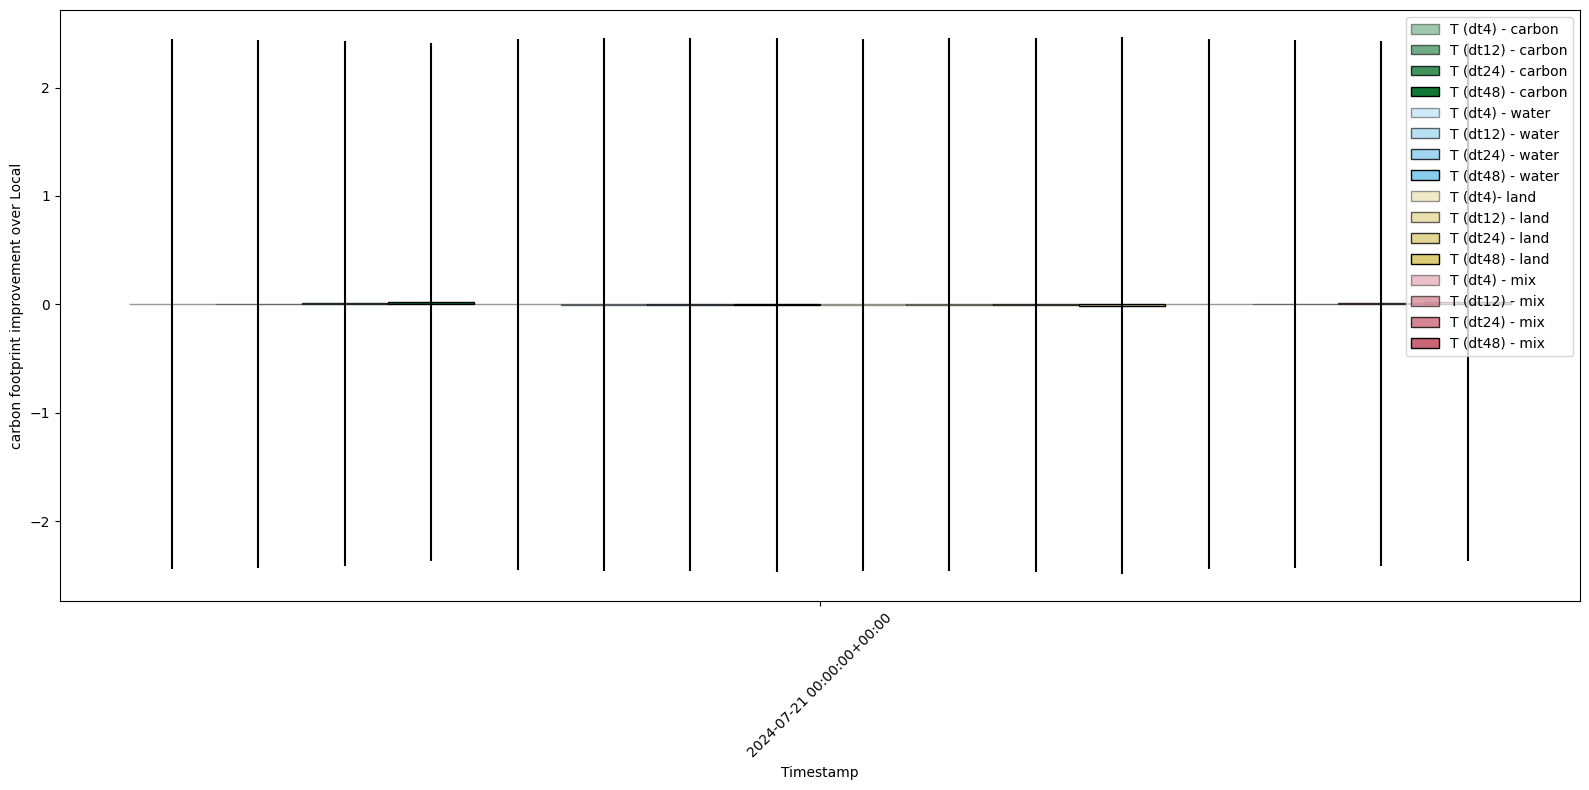

In [35]:
for plot in plots_T + plots_TR + plots_R:
    plot["function"](**plot["args"])

In [ ]:
# PLOT TO ADD
# - regional distribution over time
# - energy mix 
# 